underwriting answers:

Should the insurer accept this risk, accept it with extra premium, or decline it?

Customer applies for insurance
        ↓
Insurer evaluates risk
        ↓
Health + lifestyle + BMI + occupation + credit + other factors
        ↓
Underwriting Score
        ↓
Decision
   ┌────┼─────────────┐
   ↓    ↓             ↓
Approve Loading     Decline

UNDERWRITING_ID
POLICY_ID
CUSTOMER_ID
AGE
HEALTH_SCORE
LIFESTYLE
MEDICAL_HISTORY_FLAG
SMOKER_FLAG
BMI
OCCUPATION_RISK
CREDIT_SCORE
UNDERWRITING_SCORE
DECISION
PREMIUM_LOADING_PCT

Grain
1 row = 1 underwriting assessment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data" / "raw"

underwriting_df = pd.read_csv(
    DATA_DIR / "underwriting.csv"
)

policies_df = pd.read_csv(
    DATA_DIR / "policies.csv"
)

print("Underwriting:", underwriting_df.shape)
print("Policies    :", policies_df.shape)

Underwriting: (50000, 14)
Policies    : (150000, 15)


In [3]:
underwriting_df.head()


underwriting_df.info()


underwriting_df.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UNDERWRITING_ID       50000 non-null  str    
 1   POLICY_ID             50000 non-null  str    
 2   CUSTOMER_ID           50000 non-null  str    
 3   AGE                   50000 non-null  int64  
 4   HEALTH_SCORE          50000 non-null  int64  
 5   LIFESTYLE             50000 non-null  str    
 6   MEDICAL_HISTORY_FLAG  50000 non-null  str    
 7   SMOKER_FLAG           50000 non-null  str    
 8   BMI                   50000 non-null  float64
 9   OCCUPATION_RISK       50000 non-null  str    
 10  CREDIT_SCORE          50000 non-null  int64  
 11  UNDERWRITING_SCORE    50000 non-null  int64  
 12  DECISION              50000 non-null  str    
 13  PREMIUM_LOADING_PCT   48463 non-null  float64
dtypes: float64(2), int64(4), str(8)
memory usage: 5.3 MB


['UNDERWRITING_ID',
 'POLICY_ID',
 'CUSTOMER_ID',
 'AGE',
 'HEALTH_SCORE',
 'LIFESTYLE',
 'MEDICAL_HISTORY_FLAG',
 'SMOKER_FLAG',
 'BMI',
 'OCCUPATION_RISK',
 'CREDIT_SCORE',
 'UNDERWRITING_SCORE',
 'DECISION',
 'PREMIUM_LOADING_PCT']

Loaded Premium
=
Base Premium × (1 + Loading % / 100)

Underwriting decisions

In [4]:
underwriting_df[
    "DECISION"
].value_counts()

DECISION
Approved                 41717
Approved with Loading     6746
Declined                  1537
Name: count, dtype: int64

In [6]:
decision_summary = (underwriting_df[ "DECISION" ].value_counts(normalize=True).mul(100).round(2))

decision_summary

DECISION
Approved                 83.43
Approved with Loading    13.49
Declined                  3.07
Name: proportion, dtype: float64

96.9%

of assessed applications are accepted in some form.

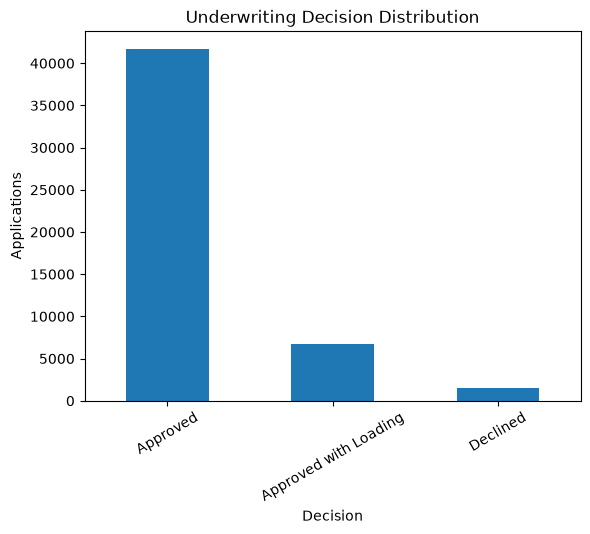

In [ ]:
underwriting_df["DECISION"].value_counts().plot(kind="bar")

plt.title(
    "Underwriting Decision Distribution"
)

plt.xlabel(
    "Decision"
)

plt.ylabel(
    "Applications"
)

plt.xticks(rotation=30)

plt.show()

In [8]:
underwriting_df.isna().sum()

UNDERWRITING_ID            0
POLICY_ID                  0
CUSTOMER_ID                0
AGE                        0
HEALTH_SCORE               0
LIFESTYLE                  0
MEDICAL_HISTORY_FLAG       0
SMOKER_FLAG                0
BMI                        0
OCCUPATION_RISK            0
CREDIT_SCORE               0
UNDERWRITING_SCORE         0
DECISION                   0
PREMIUM_LOADING_PCT     1537
dtype: int64

In [13]:
underwriting_df.groupby("DECISION")["PREMIUM_LOADING_PCT"].apply(lambda x: x.isna().sum())

DECISION
Approved                    0
Approved with Loading       0
Declined                 1537
Name: PREMIUM_LOADING_PCT, dtype: int64

In [14]:
underwriting_df[
    underwriting_df[
        "DECISION"
    ] == "Approved"
]["PREMIUM_LOADING_PCT"].describe()

count    41717.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: PREMIUM_LOADING_PCT, dtype: float64

In [15]:
underwriting_df[
    underwriting_df[
        "DECISION"
    ] == "Approved with Loading"
]["PREMIUM_LOADING_PCT"].describe()

count    6746.000000
mean       35.077951
std        14.543218
min        10.000000
25%        22.380000
50%        35.150000
75%        47.740000
max        60.000000
Name: PREMIUM_LOADING_PCT, dtype: float64

In [16]:
underwriting_df[
    "UNDERWRITING_SCORE"
].describe()

count    50000.000000
mean       604.448940
std         86.856855
min        224.000000
25%        546.000000
50%        605.000000
75%        664.000000
max        883.000000
Name: UNDERWRITING_SCORE, dtype: float64

In [17]:
score_decision_summary = (
    underwriting_df
    .groupby("DECISION")
    ["UNDERWRITING_SCORE"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
)

score_decision_summary

,count,mean,median,min,max
DECISION,,,,,
Approved,41717,630.757461,624.0,520,883
Approved with Loading,6746,487.516751,491.0,440,519
Declined,1537,403.610930,412.0,224,439


Score <= 439
        ↓
Declined


Score 440–519
        ↓
Approved with Loading


Score >= 520
        ↓
Approved

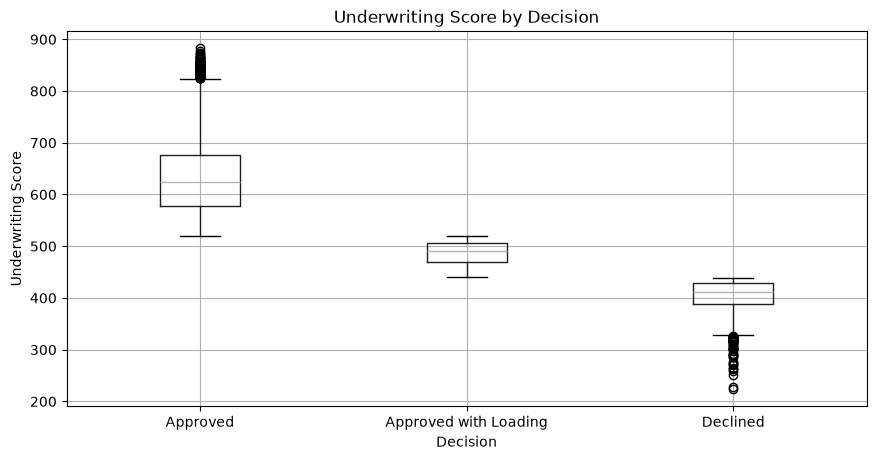

In [18]:
underwriting_df.boxplot(
    column="UNDERWRITING_SCORE",
    by="DECISION",
    figsize=(10, 5)
)

plt.title(
    "Underwriting Score by Decision"
)

plt.suptitle("")

plt.xlabel("Decision")
plt.ylabel("Underwriting Score")

plt.show()

In [19]:
health_decision_summary = (
    underwriting_df
    .groupby("DECISION")
    ["HEALTH_SCORE"]
    .mean()
)

health_decision_summary

DECISION
Approved                 79.044850
Approved with Loading    61.775719
Declined                 51.357840
Name: HEALTH_SCORE, dtype: float64

In [20]:
underwriting_df[
    "BMI"
].describe()

count    50000.000000
mean        25.503648
std          4.723345
min         16.000000
25%         22.200000
50%         25.400000
75%         28.700000
max         42.000000
Name: BMI, dtype: float64

In [21]:
(
    underwriting_df
    .groupby("DECISION")
    ["BMI"]
    .mean()
)

DECISION
Approved                 25.194384
Approved with Loading    26.876371
Declined                 27.872674
Name: BMI, dtype: float64

In [22]:
smoker_decision = pd.crosstab(
    underwriting_df["SMOKER_FLAG"],
    underwriting_df["DECISION"],
    normalize="index"
) * 100

smoker_decision.round(2)

DECISION,Approved,Approved with Loading,Declined
SMOKER_FLAG,,,
No,83.41,13.54,3.05
Yes,83.56,13.22,3.22


In [ ]:
smoker status by itself does not appear to be a strong separator of underwriting decisions in this dataset.

In [23]:
medical_decision = pd.crosstab(
    underwriting_df[
        "MEDICAL_HISTORY_FLAG"
    ],
    underwriting_df[
        "DECISION"
    ],
    normalize="index"
) * 100

medical_decision.round(2)

DECISION,Approved,Approved with Loading,Declined
MEDICAL_HISTORY_FLAG,,,
No,83.44,13.46,3.10
Yes,83.40,13.61,2.99


In [24]:
occupation_decision = pd.crosstab(
    underwriting_df[
        "OCCUPATION_RISK"
    ],
    underwriting_df[
        "DECISION"
    ],
    normalize="index"
) * 100

occupation_decision.round(2)

DECISION,Approved,Approved with Loading,Declined
OCCUPATION_RISK,,,
High,82.85,13.95,3.20
Low,83.58,13.35,3.07
Medium,83.27,13.68,3.05


In [26]:
lifestyle_summary = pd.crosstab(
    underwriting_df[
        "LIFESTYLE"
    ],
    underwriting_df[
        "DECISION"
    ],
    normalize="index"
) * 100

lifestyle_summary.round(2)

DECISION,Approved,Approved with Loading,Declined
LIFESTYLE,,,
Average,82.84,13.86,3.30
Excellent,83.61,13.58,2.81
Good,83.58,13.34,3.08
Poor,84.43,12.73,2.84


Create Loading Bands

In [27]:
loaded_df = underwriting_df[
    underwriting_df[
        "DECISION"
    ] == "Approved with Loading"
].copy()

In [28]:
loaded_df[
    "LOADING_BAND"
] = pd.cut(
    loaded_df[
        "PREMIUM_LOADING_PCT"
    ],
    bins=[
        0,
        20,
        40,
        60
    ],
    labels=[
        "10-20%",
        "20-40%",
        "40-60%"
    ],
    include_lowest=True
)

In [29]:
loaded_df[
    "LOADING_BAND"
].value_counts().sort_index()

LOADING_BAND
10-20%    1339
20-40%    2672
40-60%    2735
Name: count, dtype: int64

Merge with Policies

Now let's connect underwriting to the actual insurance product.

Underwriting
     ↓
Policy


In [30]:
underwriting_policy_df = underwriting_df.merge(
    policies_df[
        [
            "POLICY_ID",
            "POLICY_TYPE",
            "ANNUAL_PREMIUM",
            "SUM_INSURED",
            "RISK_SCORE",
            "RISK_BAND",
            "POLICY_STATUS"
        ]
    ],
    on="POLICY_ID",
    how="left",
    validate="one_to_one"
)

In [31]:
product_underwriting = (
    underwriting_policy_df
    .groupby("POLICY_TYPE")
    .agg(
        APPLICATIONS=(
            "UNDERWRITING_ID",
            "count"
        ),

        APPROVED=(
            "DECISION",
            lambda x:
            (x == "Approved").sum()
        ),

        APPROVED_WITH_LOADING=(
            "DECISION",
            lambda x:
            (
                x == "Approved with Loading"
            ).sum()
        ),

        DECLINED=(
            "DECISION",
            lambda x:
            (x == "Declined").sum()
        ),

        AVG_UNDERWRITING_SCORE=(
            "UNDERWRITING_SCORE",
            "mean"
        ),

        AVG_LOADING_PCT=(
            "PREMIUM_LOADING_PCT",
            "mean"
        )
    )
    .reset_index()
)

In [32]:
product_underwriting["DECLINE_RATE"] = (
    product_underwriting["DECLINED"] / product_underwriting["APPLICATIONS"]
) * 100

In [33]:
product_underwriting.sort_values("DECLINE_RATE",ascending=False)

,POLICY_TYPE,APPLICATIONS,APPROVED,APPROVED_WITH_LOADING,DECLINED,AVG_UNDERWRITING_SCORE,AVG_LOADING_PCT,DECLINE_RATE
2,Home,4028,3357,537,134,604.471698,4.931102,3.326713
4,Personal Accident,4040,3355,552,133,604.068317,4.863005,3.292079
6,Travel,3011,2503,410,98,604.125540,4.948747,3.254733
5,Term Life,8104,6762,1086,256,604.314289,4.862602,3.158934
0,Commercial,4956,4135,668,153,604.274213,4.864889,3.087167
1,Health,11984,9988,1633,363,604.325684,4.941200,3.029039
7,Whole Life,3340,2770,471,99,604.772754,5.079438,2.964072
3,Motor,10537,8847,1389,301,604.901870,4.748611,2.856601


Compare Underwriting Score with Policy Risk Score

In [34]:
underwriting_policy_df[
    [
        "UNDERWRITING_SCORE",
        "RISK_SCORE"
    ]
].corr()

,UNDERWRITING_SCORE,RISK_SCORE
UNDERWRITING_SCORE,1.000000,-0.078448
RISK_SCORE,-0.078448,1.000000


If correlation is low:

Policy risk score and underwriting score appear to measure different constructs or were generated independently.

If high:

They may contain overlapping risk information.

In [35]:
# Build policy-level underwriting features
policy_underwriting_features = (
    underwriting_df[
        [
            "POLICY_ID",
            "CUSTOMER_ID",
            "AGE",
            "HEALTH_SCORE",
            "LIFESTYLE",
            "MEDICAL_HISTORY_FLAG",
            "SMOKER_FLAG",
            "BMI",
            "OCCUPATION_RISK",
            "CREDIT_SCORE",
            "UNDERWRITING_SCORE",
            "DECISION",
            "PREMIUM_LOADING_PCT"
        ]
    ]
    .copy()
)

In [36]:
policy_underwriting_features["UW_APPROVED_FLAG"] = (policy_underwriting_features["DECISION"] == "Approved").astype(int)

policy_underwriting_features["UW_LOADING_FLAG"] = (policy_underwriting_features["DECISION"] == "Approved with Loading").astype(int)

policy_underwriting_features["UW_DECLINED_FLAG"] = (policy_underwriting_features["DECISION"] == "Declined").astype(int)

In [37]:
policy_underwriting_features[
    "POLICY_ID"
].duplicated().sum()

np.int64(0)

In [38]:
policy_underwriting_features.shape

(50000, 16)

In [39]:
PROCESSED_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [40]:
policy_underwriting_features.to_csv(
    PROCESSED_DIR
    / "policy_underwriting_features.csv",
    index=False
)

50K Underwriting Assessments
        ↓
83.43% Approved
        ↓
13.49% Approved with Loading
        ↓
3.07% Declined
        ↓
Loaded cases average ~35% extra premium
        ↓
Health score differs noticeably by decision
        ↓
Individual smoker / occupation / lifestyle
distributions are relatively similar
        ↓
Underwriting Score almost completely
determines the Decision
        ↓
Decision thresholds discovered:
<=439     → Declined
440–519   → Loading
>=520     → Approved